In [8]:
from binance.um_futures import UMFutures
from database.adatabase import ADatabase
from binance_parameter_creator.binance_parameter_creator import BinanceParameterCreator as bpc
from binance_strategy.binance_strategy_factory import BinanceStrategyFactory
from crypto_parameter.acrypto_parameter import ACryptoParameter
from time import sleep
import pandas as pd
from datetime import datetime, timedelta
from binance.um_futures import UMFutures
from database.adatabase import ADatabase
from time import sleep
import pandas as pd
import random
import matplotlib.pyplot as plt
import pytz
kst_timezone = pytz.timezone('Asia/Seoul')

In [9]:
db = ADatabase("sapling")
db.cloud_connect()
bots = db.retrieve("crypto_bots")
keys = db.retrieve("crypto_secrets")
parameters = db.retrieve("crypto_parameter")
db.disconnect()
## parameters
for bot in bots.iterrows():
    user = bot[1]["username"]
    live = bot[1]["live"]
    if live == True:
        parameter = parameters[parameters["username"]==user].to_dict("records")[0]
        ticker = parameter["ticker"]
        secret = keys[keys["username"]==user]["bsecret"].item()
        key = keys[keys["username"]==user]["bkey"].item()
        umf = UMFutures(key,secret)
        account = umf.account()
        trades = umf.get_account_trades("XRPUSDT")
        trades = pd.DataFrame(trades)
        print(account["totalUnrealizedProfit"])
        positions = pd.DataFrame(account["positions"])
        xrp_positions = positions[positions["symbol"]==ticker]
        orders = pd.DataFrame(umf.get_all_orders("XRPUSDT"))
        new_orders = orders[orders["status"]=="NEW"]
        

-0.33750000


In [20]:
xrp_positions.columns

Index(['symbol', 'initialMargin', 'maintMargin', 'unrealizedProfit',
       'positionInitialMargin', 'openOrderInitialMargin', 'leverage',
       'isolated', 'entryPrice', 'breakEvenPrice', 'maxNotional',
       'positionSide', 'positionAmt', 'notional', 'isolatedWallet',
       'updateTime', 'bidNotional', 'askNotional'],
      dtype='object')

In [32]:
xrp_positions[["entryPrice","unrealizedProfit","breakEvenPrice","notional"]]

,entryPrice,unrealizedProfit,breakEvenPrice,notional
122,0.5829,-0.33750000,0.58260855,-44.05500000


In [15]:
new_orders.columns

Index(['orderId', 'symbol', 'status', 'clientOrderId', 'price', 'avgPrice',
       'origQty', 'executedQty', 'cumQuote', 'timeInForce', 'type',
       'reduceOnly', 'closePosition', 'side', 'positionSide', 'stopPrice',
       'workingType', 'priceMatch', 'selfTradePreventionMode', 'goodTillDate',
       'priceProtect', 'origType', 'time', 'updateTime', 'activatePrice',
       'priceRate'],
      dtype='object')

In [33]:
new_orders[["status","price","stopPrice","side","type","activatePrice"]]

,status,price,stopPrice,side,type,activatePrice
499,NEW,0.5820,0,BUY,LIMIT,NaN


In [12]:
trades["date"] = [datetime.utcfromtimestamp(float(x) // 1000.0).replace(tzinfo=pytz.utc).astimezone(kst_timezone) for x in trades["time"]]
trades = trades[trades["date"]>datetime(2024,2,28,16,10).astimezone(kst_timezone)]

In [13]:
trades["realizedPnl"] = [float(x) for x in trades["realizedPnl"]]
trades["commission"] = [float(x) for x in trades["commission"]]
trades["price"] = [float(x) for x in trades["price"]]
trades["w/l"] = ["W" if x > 0 else "L" if x < 0 else "N" for x in trades["realizedPnl"]]
trades = trades.groupby(["date","w/l"]).agg({"price":"mean","commission":"sum","realizedPnl":"sum"}).reset_index()
trades["agg_pnl"] = trades["realizedPnl"].cumsum()
trades["agg_commission"] = trades["commission"].cumsum()
trades["pnl"] = trades["agg_pnl"] - trades["agg_commission"]
trades["entry_price"] = trades["price"].shift(1)
trades["price_diff"] = trades["price"].pct_change() * 100
trades["net_profit"] = trades["realizedPnl"] - trades["commission"]
trades[["date","price","entry_price","price_diff","w/l","net_profit","realizedPnl","agg_pnl","commission","agg_commission","pnl"]]
    

,date,price,entry_price,price_diff,w/l,net_profit,realizedPnl,agg_pnl,commission,agg_commission,pnl
0,2024-02-28 16:11:01+09:00,0.5799,NaN,NaN,N,-0.021746,0.0000,0.0000,0.021746,0.021746,-0.021746
1,2024-02-28 16:12:26+09:00,0.5795,0.5799,-0.068977,N,-0.021731,0.0000,0.0000,0.021731,0.043478,-0.043478
2,2024-02-28 16:23:20+09:00,0.5798,0.5795,0.051769,W,0.013803,0.0225,0.0225,0.008697,0.052174,-0.029674
3,2024-02-28 16:23:26+09:00,0.5798,0.5798,0.000000,N,-0.021743,0.0000,0.0225,0.021743,0.073917,-0.051417
4,2024-02-28 16:33:36+09:00,0.5795,0.5798,-0.051742,W,0.013807,0.0225,0.0450,0.008693,0.082610,-0.037610
5,2024-02-28 16:33:47+09:00,0.5799,0.5795,0.069025,N,-0.021746,0.0000,0.0450,0.021746,0.104356,-0.059356
6,2024-02-28 16:45:51+09:00,0.5815,0.5799,0.275910,W,0.098194,0.1200,0.1650,0.021806,0.126162,0.038838
7,2024-02-28 16:46:21+09:00,0.5814,0.5815,-0.017197,N,-0.021802,0.0000,0.1650,0.021802,0.147964,0.017035
8,2024-02-28 16:59:23+09:00,0.5838,0.5814,0.412797,W,0.158107,0.1800,0.3450,0.021892,0.169857,0.175143
9,2024-02-28 16:59:35+09:00,0.5835,0.5838,-0.051387,N,-0.021881,0.0000,0.3450,0.021881,0.191738,0.153262


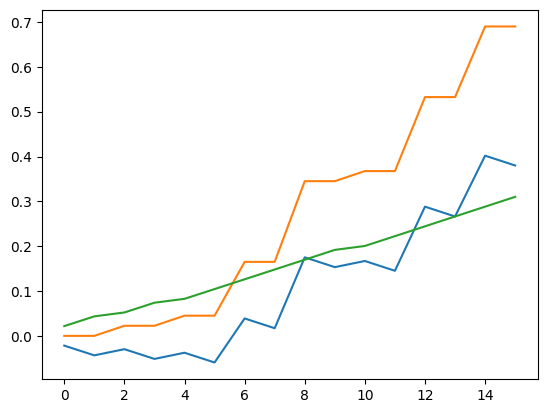

In [14]:
plt.plot(trades["pnl"])
plt.plot(trades["agg_pnl"])
plt.plot(trades["agg_commission"])
plt.show()